# GNN-Correlation Hyperparameter Search (Round 2)

Grid search over architecture and training hyperparameters for GNN-Correlation.
Fixed at θ=0.3 (ablation winner from 04_gnn_models.ipynb).

Round 1 (48 configs) findings used to prune the grid:
- num_layers=3 won all top-5 slots → fixed at 3
- hidden_dim=64 never appeared in top 5 → replaced with 256
- lr=3e-3 never appeared in top 5, winner was at the low end → dropped, added 1e-4
- batch_norm=True (BatchNorm1d) never appeared in top 10 → now means GraphNorm, re-tested
- dropout: both 0.1 and 0.3 appeared in top 5 → kept

Grid: lr × hidden_dim × dropout × batch_norm = 3 × 2 × 2 × 2 = 24 configs.

Resumable: if a run's checkpoint exists it is skipped, so you can restart after a Colab timeout.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import json
import itertools
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import config
from src.models import GNNModelV2
from src.train import set_seeds, run_gnn_hparam_search
from src.graphs import load_corr_graphs

In [2]:
# Load features, target, splits — same pattern as 04_gnn_models.ipynb
target = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'target.parquet')
splits = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'splits.parquet')
tickers = target.columns.tolist()

meta          = json.load(open(Path(config.DATA_FEATURES_DIR) / 'features_meta.json'))
feature_names = meta['feature_names']
feat_df       = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'features.parquet')
feat_df['week'] = pd.to_datetime(feat_df['week'])
feat_df = feat_df[feat_df['week'].isin(target.index)].copy()
ticker_order    = {t: i for i, t in enumerate(tickers)}
feat_df['_ord'] = feat_df['ticker'].map(ticker_order)
feat_df = feat_df.sort_values(['week', '_ord']).drop(columns='_ord')

n_weeks  = target.shape[0]
n_stocks = target.shape[1]
n_feats  = len(feature_names)

features_3d = feat_df[feature_names].values.reshape(n_weeks, n_stocks, n_feats)
target_arr  = target.values

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

assert features_3d.shape == (n_weeks, n_stocks, n_feats)
assert target_arr.shape  == (n_weeks, n_stocks)
print(f'features_3d: {features_3d.shape}  target_arr: {target_arr.shape}')
print(f'tickers: {len(tickers)}  n_feats: {n_feats}  device: {device}')

features_3d: (572, 465, 10)  target_arr: (572, 465)
tickers: 465  n_feats: 10  device: cuda


In [3]:
# Load precomputed correlation graphs at θ=0.3 for train and val weeks.
# precompute_corr_graphs() was already run in 04_gnn_models.ipynb so this is a fast dict load.
theta = config.CORR_THRESHOLD  # 0.3
corr_graphs_03 = {
    **load_corr_graphs(theta, 'train'),
    **load_corr_graphs(theta, 'val'),
}
print(f'Loaded {len(corr_graphs_03)} weeks of correlation graphs at θ={theta}')

Loaded 469 weeks of correlation graphs at θ=0.3


In [4]:
# Show the full grid before starting.
grid = [
    {
        'lr': lr,
        'hidden_dim': hd,
        'dropout': do,
        'batch_norm': bn,
        'num_layers': nl,
    }
    for lr in config.GNN_HPARAM_LR
    for hd in config.GNN_HPARAM_HIDDEN
    for do in config.GNN_HPARAM_DROPOUT
    for bn in config.GNN_HPARAM_BATCH_NORM
    for nl in config.GNN_HPARAM_NUM_LAYERS
]

grid_df = pd.DataFrame(grid)
grid_df.index.name = 'config_idx'

print(f'Total configs: {len(grid)}')
print(f'\nGrid axes:')
print(f'  lr         : {config.GNN_HPARAM_LR}')
print(f'  hidden_dim : {config.GNN_HPARAM_HIDDEN}')
print(f'  dropout    : {config.GNN_HPARAM_DROPOUT}')
print(f'  batch_norm : {config.GNN_HPARAM_BATCH_NORM}  (True = GraphNorm)')
print(f'  num_layers : {config.GNN_HPARAM_NUM_LAYERS}  (fixed at 3)')
print(f'  patience   : {config.GNN_HPARAM_PATIENCE} epochs')
print()

# Round 1 winner — target to beat
round1_best_mse = 0.019589
round1_best_cfg = {'lr': 3e-4, 'hidden_dim': 128, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 3}
print(f'Round 1 best val MSE : {round1_best_mse:.6f}')
print(f'Round 1 best config  : {round1_best_cfg}')
print(f'Note: batch_norm=True now uses GraphNorm instead of BatchNorm1d.')

Total configs: 24

Grid axes:
  lr         : [0.0001, 0.0003, 0.001]
  hidden_dim : [128, 256]
  dropout    : [0.1, 0.3]
  batch_norm : [True, False]  (True = GraphNorm)
  num_layers : [3]  (fixed at 3)
  patience   : 7 epochs

Round 1 best val MSE : 0.019589
Round 1 best config  : {'lr': 0.0003, 'hidden_dim': 128, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 3}
Note: batch_norm=True now uses GraphNorm instead of BatchNorm1d.


In [5]:
results_df, best_config = run_gnn_hparam_search(
    features=features_3d,
    target=target_arr,
    week_index=target.index,
    corr_graphs=corr_graphs_03,
    splits=splits,
    device=device,
    grid=grid,
    max_epochs=config.GNN_MAX_EPOCHS,
)


Config 1/24  [hparam_000]
  lr=0.0001  hidden=128  dropout=0.1  batch_norm=True  num_layers=3
  Parameters: 69,761


c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Epoch   1  train=0.072301  val=0.031225
Epoch   2  train=0.054578  val=0.028803
Epoch   3  train=0.050105  val=0.027574
Epoch   4  train=0.047230  val=0.026879
Epoch   5  train=0.045339  val=0.026441
Epoch   6  train=0.044101  val=0.025916
Epoch   7  train=0.043052  val=0.025602
Epoch   8  train=0.042146  val=0.025443
Epoch   9  train=0.041508  val=0.025386
Epoch  10  train=0.040984  val=0.025174
Epoch  11  train=0.040424  val=0.025033
Epoch  12  train=0.039987  val=0.024767
Epoch  13  train=0.039714  val=0.024703
Epoch  14  train=0.039283  val=0.024625
Epoch  15  train=0.038854  val=0.024231
Epoch  16  train=0.038738  val=0.024184
Epoch  17  train=0.038388  val=0.024157
Epoch  18  train=0.038304  val=0.023978
Epoch  19  train=0.037989  val=0.023801
Epoch  20  train=0.037843  val=0.023724
Epoch  21  train=0.037670  val=0.023738
Epoch  22  train=0.037495  val=0.023604
Epoch  23  train=0.037302  val=0.023453
Epoch  24  train=0.037139  val=0.023293
Epoch  25  train=0.036951  val=0.023264


In [6]:
import json, shutil
import pandas as pd
from pathlib import Path
import config

results_dir = Path(config.DATA_RESULTS_DIR)
ckpt_dir    = Path(config.CHECKPOINTS_DIR)

# Rebuild the same grid (identical order to the search)
grid = [
    {"lr": lr, "hidden_dim": hd, "dropout": do, "batch_norm": bn, "num_layers": nl}
    for lr in config.GNN_HPARAM_LR
    for hd in config.GNN_HPARAM_HIDDEN
    for do in config.GNN_HPARAM_DROPOUT
    for bn in config.GNN_HPARAM_BATCH_NORM
    for nl in config.GNN_HPARAM_NUM_LAYERS
]

run_records = []
missing = []
for i, cfg in enumerate(grid):
    loss_path = results_dir / f"gnn_hparam_{i:03d}_val_loss.json"
    ckpt_path = ckpt_dir    / f"gnn_hparam_{i:03d}_best.pt"
    if loss_path.exists():
        with open(loss_path) as fh:
            val_mse = json.load(fh)["best_val_loss"]
        run_records.append({**cfg, "config_idx": i, "val_mse": val_mse,
                            "checkpoint": str(ckpt_path)})
    else:
        missing.append(i)

print(f"Recovered {len(run_records)}/48 configs.  Missing: {missing}")

results_df = pd.DataFrame(run_records).sort_values("val_mse").reset_index(drop=True)
best_row   = results_df.iloc[0]
_type      = {"lr": float, "hidden_dim": int, "dropout": float, "batch_norm": bool, "num_layers": int}
best_config = {k: _type[k](best_row[k]) for k in _type}

best_src = ckpt_dir / f"gnn_hparam_{int(best_row['config_idx']):03d}_best.pt"
best_dst = ckpt_dir / "gnn_corr_hparam_best.pt"
shutil.copy2(best_src, best_dst)

results_path = results_dir / "gnn_hparam_search_results.json"
with open(results_path, "w") as fh:
    json.dump({"runs": run_records, "best_config": best_config,
                "best_val_mse": float(best_row["val_mse"]), "baseline_val_mse": None}, fh, indent=2)

print(f"\nBest val MSE : {best_row['val_mse']:.6f}")
print(f"Best config  : {best_config}")
print(f"Checkpoint   : {best_dst}")
print(f"\nTop 5:")
print(results_df[["lr","hidden_dim","dropout","batch_norm","num_layers","val_mse"]].head(5).to_string(index=True))

Recovered 24/48 configs.  Missing: []

Best val MSE : 0.019646
Best config  : {'lr': 0.001, 'hidden_dim': 256, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 3}
Checkpoint   : C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\checkpoints\gnn_corr_hparam_best.pt

Top 5:
       lr  hidden_dim  dropout  batch_norm  num_layers   val_mse
0  0.0010         256      0.3       False           3  0.019646
1  0.0010         128      0.3       False           3  0.019768
2  0.0010         128      0.1       False           3  0.019781
3  0.0003         128      0.1       False           3  0.019788
4  0.0010         256      0.1       False           3  0.020075


In [7]:
# Reload results from JSON in case this cell is run after a kernel restart.
results_path = Path(config.DATA_RESULTS_DIR) / 'gnn_hparam_search_results.json'
with open(results_path) as fh:
    saved = json.load(fh)

results_df = (
    pd.DataFrame(saved['runs'])
    .sort_values('val_mse')
    .reset_index(drop=True)
)
best_config = saved['best_config']

# Compare against round 1 winner
round1_best_mse = 0.019589
results_df['vs_round1'] = (results_df['val_mse'] - round1_best_mse) / round1_best_mse * 100

display_cols = ['lr', 'hidden_dim', 'dropout', 'batch_norm', 'num_layers', 'val_mse', 'vs_round1']

print(f'Top 10 configs (sorted by val MSE):')
print(results_df[display_cols].head(10).to_string(index=True, float_format=lambda x: f'{x:.6f}'))
print()
print(f'Round 1 best val MSE  : {round1_best_mse:.6f}  (lr=3e-4, hidden=128, dropout=0.3, GraphNorm=False, layers=3)')
print(f'Round 2 best val MSE  : {results_df["val_mse"].iloc[0]:.6f}')
delta = (results_df['val_mse'].iloc[0] - round1_best_mse) / round1_best_mse * 100
print(f'Change vs round 1     : {delta:+.2f}%')
print()
print(f'Best config: {best_config}')

Top 10 configs (sorted by val MSE):
        lr  hidden_dim  dropout  batch_norm  num_layers  val_mse  vs_round1
0 0.001000         256 0.300000       False           3 0.019646   0.289528
1 0.001000         128 0.300000       False           3 0.019768   0.913032
2 0.001000         128 0.100000       False           3 0.019781   0.980803
3 0.000300         128 0.100000       False           3 0.019788   1.016627
4 0.001000         256 0.100000       False           3 0.020075   2.480822
5 0.000300         128 0.300000        True           3 0.020094   2.579272
6 0.001000         128 0.300000        True           3 0.020249   3.368718
7 0.000300         256 0.300000       False           3 0.020418   4.233079
8 0.000100         128 0.300000       False           3 0.020489   4.595508
9 0.000300         256 0.100000       False           3 0.020533   4.819699

Round 1 best val MSE  : 0.019589  (lr=3e-4, hidden=128, dropout=0.3, GraphNorm=False, layers=3)
Round 2 best val MSE  : 0.01964

NameError: name 'baseline_mse' is not defined

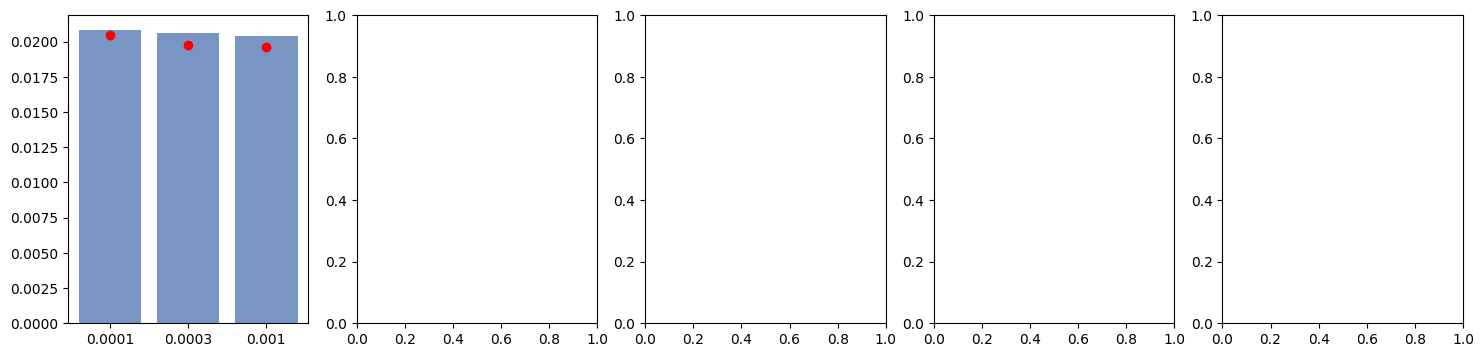

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

params = [
    ('lr',          'Learning rate'),
    ('hidden_dim',  'Hidden dim'),
    ('dropout',     'Dropout'),
    ('batch_norm',  'Batch norm'),
    ('num_layers',  'Num layers'),
]

for ax, (col, label) in zip(axes, params):
    group_mean = results_df.groupby(col)['val_mse'].mean()
    group_min  = results_df.groupby(col)['val_mse'].min()
    x_vals = [str(v) for v in group_mean.index]
    ax.bar(x_vals, group_mean.values, color='#4C72B0', alpha=0.75, label='mean MSE')
    ax.scatter(x_vals, group_min.values, color='red', zorder=5, label='min MSE')
    ax.axhline(baseline_mse, color='black', linestyle='--', linewidth=1,
               label=f'baseline {baseline_mse:.4f}')
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Val MSE')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Mean and min val MSE by hyperparameter value\n(red dot = best single config with that value)', y=1.02)
plt.tight_layout()
plt.savefig(Path(config.FIGURES_DIR) / 'gnn_hparam_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/gnn_hparam_search.png')

In [ ]:
# Load the best checkpoint and verify it produces valid predictions on a sample week.
best_ckpt = Path(config.CHECKPOINTS_DIR) / 'gnn_corr_hparam_best.pt'
assert best_ckpt.exists(), f'Best checkpoint not found: {best_ckpt}'

set_seeds()
best_model = GNNModelV2(
    in_channels=n_feats,
    hidden_dim=best_config['hidden_dim'],
    dropout=best_config['dropout'],
    num_layers=best_config['num_layers'],
    batch_norm=best_config['batch_norm'],
).to(device)
best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
best_model.eval()

# Pick a validation week for a quick sanity check
val_weeks = splits.loc[splits['split'] == 'val', 'week'].sort_values()
sample_week = val_weeks.iloc[25]  # mid-val
sample_pos  = list(target.index).index(sample_week)

sample_ei = corr_graphs_03.get(sample_week, torch.zeros(2, 0, dtype=torch.long)).to(device)
x_sample  = torch.tensor(features_3d[sample_pos], dtype=torch.float32).to(device)

with torch.no_grad():
    pred = best_model(x_sample, sample_ei)

print(f'Best model architecture:')
print(best_model)
print(f'\nParameters: {sum(p.numel() for p in best_model.parameters()):,}')
print(f'\nSanity check at {sample_week.date()}:')
print(f'  Output shape : {tuple(pred.shape)}')
print(f'  NaNs         : {pred.isnan().sum().item()}')
print(f'  min / max    : {pred.min().item():.4f} / {pred.max().item():.4f}')
print(f'\nCheckpoint    : {best_ckpt}')